# Regression Analysis Project

## Importing Libraries

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [6]:
house_price = pd.read_csv("dataset/house_price.csv")

## Data Inspection

In [3]:
# Top 5 rows
house_price.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
# Basic Information
house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [5]:
# Summary Statistics
house_price.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [6]:
house_price.shape

(1000, 8)

## Data Cleaning

In [7]:
# Check missing values
house_price.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [8]:
# Check duplicates if exists
house_price.duplicated().sum()

0

In [9]:
# Rename the House Price column for clearity
house_price = house_price.rename(columns = {"House_Price" : "Price"})

## Exploratory Data Analysis

### Data Visualisation

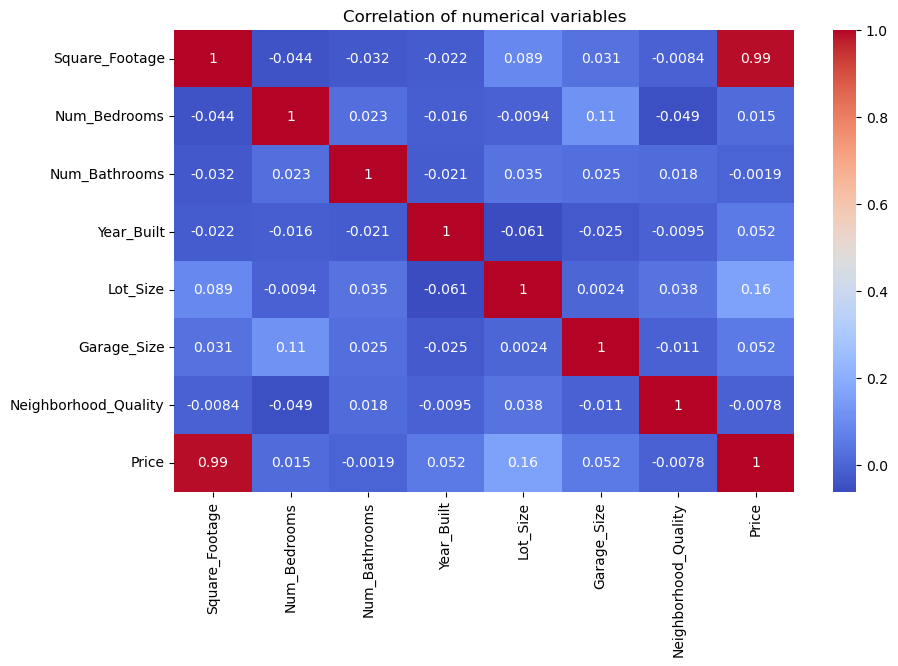

In [10]:
# Correlation Heatmap
plt.figure(figsize = (10,6))
sns.heatmap(house_price.corr(),annot = True, cmap = "coolwarm")
plt.title("Correlation of numerical variables")
plt.show()

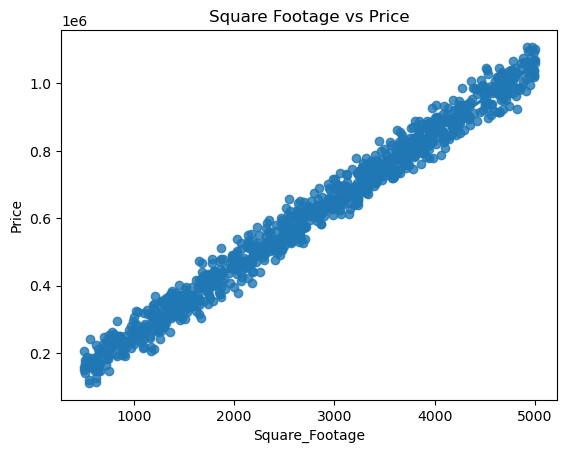

In [11]:
sns.regplot(x = house_price["Square_Footage"],y =  house_price["Price"])
plt.title("Square Footage vs Price")
plt.show()

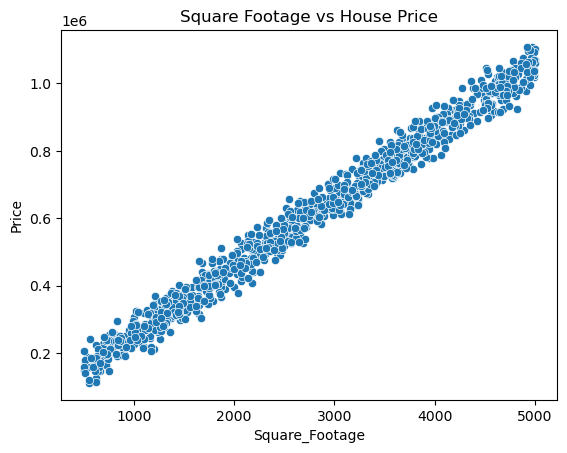

In [12]:
# Scatter plot
sns.scatterplot(x = house_price["Square_Footage"], y =house_price["Price"])
plt.title("Square Footage vs House Price")
plt.show()

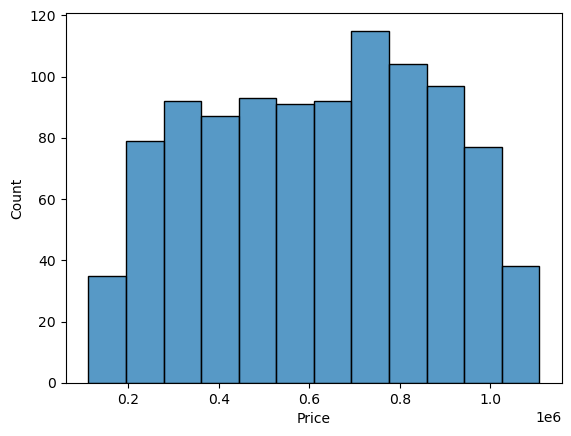

In [13]:
# Distribution plot
sns.histplot(house_price["Price"])
plt.show()

## Feature Selection

In [7]:
# Indepentent Variable
X = house_price[["Square_Footage"]]
X

,Square_Footage
0,1360
1,4272
2,3592
3,966
4,4926
...,...
995,3261
996,3179
997,2606
998,4723


In [10]:
# Depentent Vriable
y = house_price["Price"]
y

0      2.623829e+05
1      9.852609e+05
2      7.779774e+05
3      2.296989e+05
4      1.041741e+06
           ...     
995    7.014940e+05
996    6.837232e+05
997    5.720240e+05
998    9.648653e+05
999    7.425993e+05
Name: Price, Length: 1000, dtype: float64

## Split Dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

## Build Linear Regression Model

In [12]:
# Create the model
model = LinearRegression()

In [13]:
# Feed data to  the model
model.fit(X_train,y_train)

LinearRegression()

## Making Predition 

In [14]:
y_pred = model.predict(X_test)
y_pred

array([ 858863.24859834,  517515.44416559,  998450.83489986,
       1043375.57531874,  785459.43166392,  773426.01905172,
        984411.85351896,  881927.28943839,  812534.61004137,
        905191.88715531,  778239.3840966 ,  669537.55683305,
        210663.42255448, 1041971.67718065,  568657.44776744,
        231721.89462583,  492646.39143371,  396178.53365924,
        722484.57232674,  330195.321169  ,  747353.62505862,
        514306.53413567,  719275.66229682,  883932.85820709,
        444312.18410804,  345838.75756486,  452133.90230597,
        437092.13654072,  238139.71468567,  451532.23167536,
        270830.48561548,  909203.02469271,  762395.39082387,
        333805.34495266,  481615.76320586,  777838.27034286,
        476000.1706535 ,  571866.35779736,  249571.45666726,
        186797.15420695,  320969.70483298,  255187.04921962,
        498462.54086294,  309738.51972826, 1056010.65856155,
        929258.71237971,  798696.18553734,  811932.93941076,
        991030.23045567,

## Model Evaluation

### Metrics

In [15]:
# Mean squared Error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
print("MSE : ", mse)
print("R2 : ", r2)

MSE :  1081485546.4889545
R2 :  0.9832220800154357


In [17]:
# Predict new house price
new_house = [[966]]
model.predict(new_house)

C:\Users\ADMIN\Anacondaa3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([247967.0016523])

## Conclusion

#### A simple Linear Regression Model was successfully developed to predict house price based on square footage.
#### The Analysis showed a strong positive relationship between house size and price, meaning that larger houses generally have higher prices. The Model learned the regression equation.